In [1]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# read the insurance.csv dataset
insurance = pd.read_csv("./insurance.csv")
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
insurance.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [4]:
X = insurance.drop("charges", axis=1)
y = insurance["charges"]

In [5]:
X = pd.get_dummies(X)

X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1070, 11), (1070,), (268, 11), (268,))

In [7]:
# standarized the columns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

preprocessor = ColumnTransformer(
    [
        ("MinMaxScaler", MinMaxScaler(), ["age", "bmi", "children"]),
        # we can one-hot-encode other categorical columns but but we already done it using .get_dummies method
    ],
    remainder="passthrough",
)

In [8]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [9]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,10
0,0.608696,0.107345,0.4,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.630435,0.224913,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,0.739130,0.239440,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.456522,0.493947,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.782609,0.148238,0.6,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1065,0.000000,0.414044,0.8,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1066,0.456522,0.212806,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1067,0.869565,0.247915,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
1068,0.413043,0.851224,0.4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [10]:
tf.random.set_seed(42)

# create a model
insurance_model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=X_train.shape[1:]),
        tf.keras.layers.Dense(100, activation=tf.keras.activations.relu),
        tf.keras.layers.Dense(100, activation=tf.keras.activations.relu),
        tf.keras.layers.Dense(10, activation=tf.keras.activations.relu),
        tf.keras.layers.Dense(1),
    ]
)

# compile a model
insurance_model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["mae"],
)

In [11]:
history = insurance_model.fit(X_train, y_train, epochs=125)

Epoch 1/125
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 13297.8662 - mae: 13297.8662
Epoch 2/125
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13289.6182 - mae: 13289.6182 
Epoch 3/125
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13244.3096 - mae: 13244.3096
Epoch 4/125
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13077.8232 - mae: 13077.8232
Epoch 5/125
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12641.3936 - mae: 12641.3936
Epoch 6/125
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11737.0420 - mae: 11737.0420
Epoch 7/125
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10384.4199 - mae: 10384.4199 
Epoch 8/125
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8972.4326 - mae: 8972.4326 
Epoch 9/125
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8090.6543 - mae: 8090.6543
Epoch 10/125
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7833.0034 - mae: 7833.0034
Epoch 11/125
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7718.0146 - mae: 7718.0146
Epoch 12/125
34/34 ━━━━━━━━━━━━━━━━

In [12]:
insurance_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,965 (144.40 KB)

 Trainable params: 12,321 (48.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 24,644 (96.27 KB)

In [13]:
insurance_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2901.3069 - mae: 2901.3069  


[2808.841552734375, 2808.841552734375]

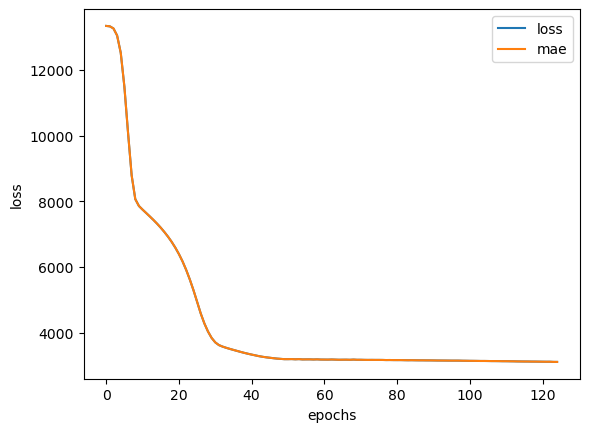

In [14]:
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")
plt.show()

# we can stop this likely at 50